In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/reg_mixer_attnpl_t_20260202-000622") 
# checkpoints/reg_mixer_attnpl_t_20260131-114145
checkpoint_path = checkpoint_dir / "last_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inp

In [3]:
model.eval()
model.extractor.g

Parameter containing:
tensor([-0.0101, -0.0186, -0.0544, -0.0409], device='cuda:0',
       requires_grad=True)

In [4]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/regressor/regressor_Mc_3_Mf_3_Tfore_180_Twindow_360_context_le

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [6]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

In [7]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    

In [8]:
# model.base_model.input_adapter(x)['features'][0,:,0]

In [9]:
# model.base_model.encoder

In [10]:
model.base_model.encoder.input_proj(model.base_model.input_adapter(x)['features'])[0,0,:]

tensor([-1.1383e-01,  1.9200e-01,  1.6776e-01,  1.2600e-01,  6.6137e-02,
        -1.8193e-02,  1.7433e-01,  3.1346e-01,  2.1619e-01,  4.4539e-02,
         5.1245e-02, -2.0009e-04, -2.0617e-01,  5.7634e-02,  1.6331e-01,
         1.0969e-01,  1.6972e-01,  2.5979e-03, -3.0819e-01,  7.7144e-02,
        -6.4538e-02,  4.6189e-02,  1.5149e-01,  1.1070e-01,  8.7748e-02,
        -1.3720e-01, -3.4080e-01, -1.9323e-02, -1.2295e-01, -2.1684e-01,
        -1.0970e-01, -2.6914e-01,  1.7344e-01, -1.0762e-01, -1.0079e-01,
        -6.1167e-02,  1.2650e-01,  5.5443e-02, -6.6741e-02,  6.2361e-02,
         9.9386e-02, -1.9130e-02, -2.0385e-02, -1.7690e-01,  1.1337e-01,
        -6.0007e-02, -1.4018e-01,  6.1289e-02, -1.0005e-01, -1.5849e-01,
        -5.1345e-01,  2.3141e-01,  1.1243e-01,  3.2741e-01, -1.3345e-01,
        -3.2017e-01,  4.6380e-01, -2.0123e-01, -8.9335e-02, -1.7198e-01,
        -1.4920e-01,  7.6487e-02,  1.5337e-01,  6.2714e-02], device='cuda:0',
       grad_fn=<SliceBackward0>)

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


mean: -0.0028135129250586033
std : 0.23872533440589905
min : -2.9894847869873047
max : 3.5839898586273193


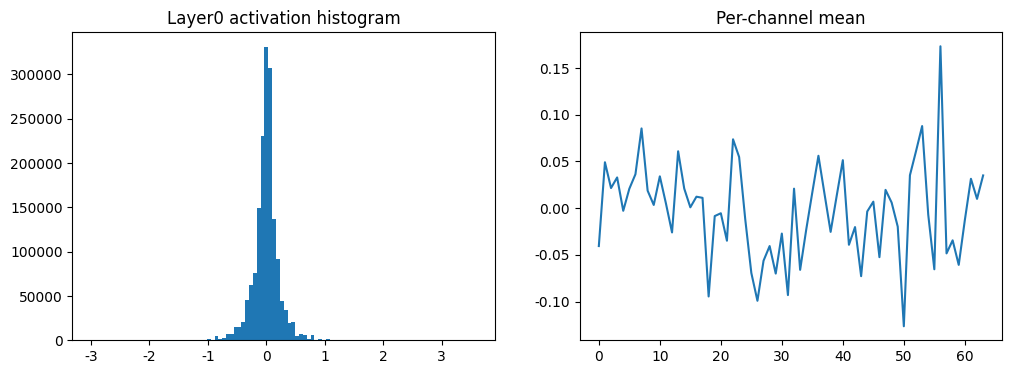

In [11]:
import matplotlib.pyplot as plt
# Capture activations after encoder layer[0]
layer0_out = []

def _hook(module, inp, out):
    # out may be tuple: (hidden_states, residual)
    if isinstance(out, tuple):
        out = out[0]

    layer0_out.append(out.detach().cpu())

# hook_handle = model.base_model.encoder.layers[0].register_forward_hook(_hook)
hook_handle = model.base_model.encoder.input_proj.register_forward_hook(_hook)

with torch.no_grad():
    _ = model(x)

hook_handle.remove()

# ===== visualize =====
if len(layer0_out) > 0:
    h = layer0_out[0]   # (B, L, D)

    # Global stats
    print("mean:", h.mean().item())
    print("std :", h.std().item())
    print("min :", h.min().item())
    print("max :", h.max().item())

    # Per-channel mean
    channel_means = h.mean(dim=(0, 1)).numpy()

    # Flatten histogram
    h_flat = h.reshape(-1).numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(h_flat, bins=100)
    plt.title("Layer0 activation histogram")

    plt.subplot(1,2,2)
    plt.plot(channel_means)
    plt.title("Per-channel mean")

    plt.show()
else:
    print("No activations captured.")

In [12]:
model.eval()
model.extractor.t_mlp.to(device)
x_ = torch.linspace(0, 1, 100).unsqueeze(1)  
x_ = x_.to(device)  
gamma, beta = model.extractor.t_mlp(x_).chunk(2, dim=-1)  

In [13]:
def predict_all(model, data_loader, device, return_X=False):
    y_pred_list = []
    y_list = []
    X_list = [] if return_X else None

    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            if return_X:
                X = model.get_pooled_representation(x)
                X_list.append(X.detach().cpu())
            y_pred = model(x)
            y_pred_list.append(y_pred.detach().cpu())
            y_list.append(y.detach().cpu())

    y_pred_all = torch.cat(y_pred_list, dim=0).cpu().numpy()
    # flatten if shape is (N,1)
    if y_pred_all.ndim == 2 and y_pred_all.shape[1] == 1:
        y_pred_all = y_pred_all.squeeze(1)
    y_all = torch.cat(y_list, dim=0).cpu().numpy()

    if return_X:
        X_all = torch.cat(X_list, dim=0).cpu().numpy()
        return y_pred_all,  y_all, X_all
    return y_pred_all, y_all, None

In [17]:
from src.utils.metrics import regression_metrics, log_metrics, plot_and_save_roc_curve
y_pred_val, y_val, X_val = predict_all(model,val_loader, device, return_X=True)

start=0
end =400
regression_metrics(y_val[start:end], y_pred_val[start:end])  

{'RMSE': 0.13681599393614974,
 'MAE': 0.11646331944963434,
 'MSE': 0.018718616196736565,
 'MAPE': 28.52969204650965,
 'R2': -0.12726649678701185,
 'PearsonR': 0.17948929700245872,
 'PearsonR_diff': 0.0493673445676497,
 'DA': 0.04419889502762431,
 'SpearmanR': -0.005509478702006795,
 'SpearmanR_diff': 0.012560099714425989,
 'DTW': 15.11941409111023,
 'DTW_normalized': 0.08307370379730895}

In [20]:
X_all = X_val
y_all = y_val
y_pred_all = y_pred_val

/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


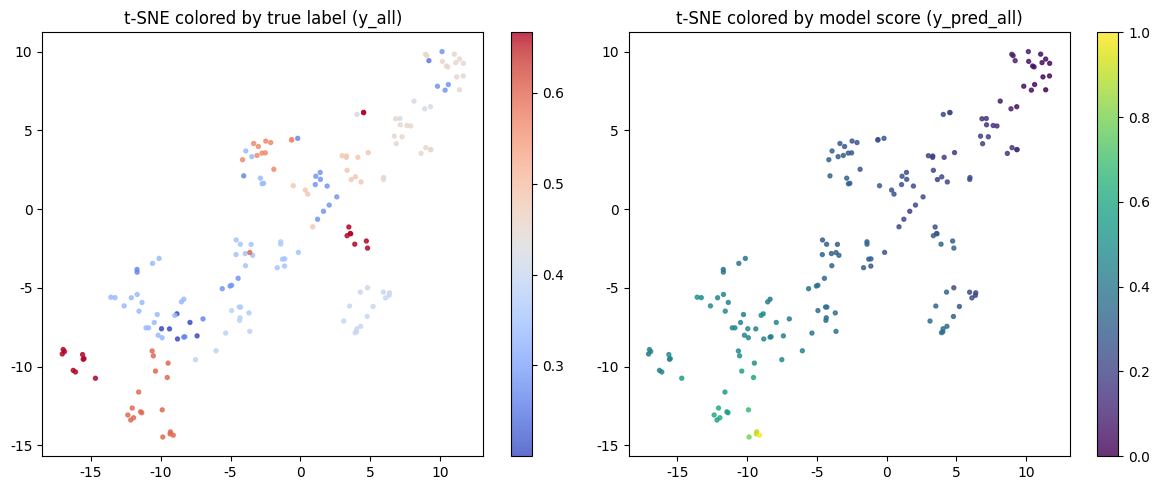

In [21]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# prepare features
X = X_all.astype(float)
X_scaled = StandardScaler().fit_transform(X)

# run t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

# normalize predictions for coloring
y_score = (y_pred_all - y_pred_all.min()) / (y_pred_all.max() - y_pred_all.min())

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axs[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all, cmap="coolwarm", s=8, alpha=0.8)
axs[0].set_title("t-SNE colored by true label (y_all)")
plt.colorbar(sc0, ax=axs[0])

sc1 = axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_score, cmap="viridis", s=8, alpha=0.8)
axs[1].set_title("t-SNE colored by model score (y_pred_all)")
plt.colorbar(sc1, ax=axs[1])

plt.tight_layout()
plt.show()

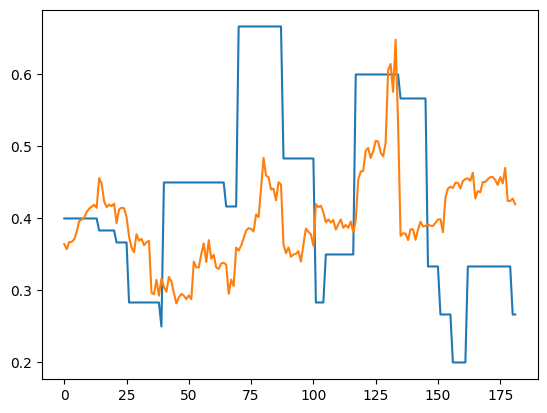

In [22]:
plt.plot(y_all,)
plt.plot(y_pred_all)

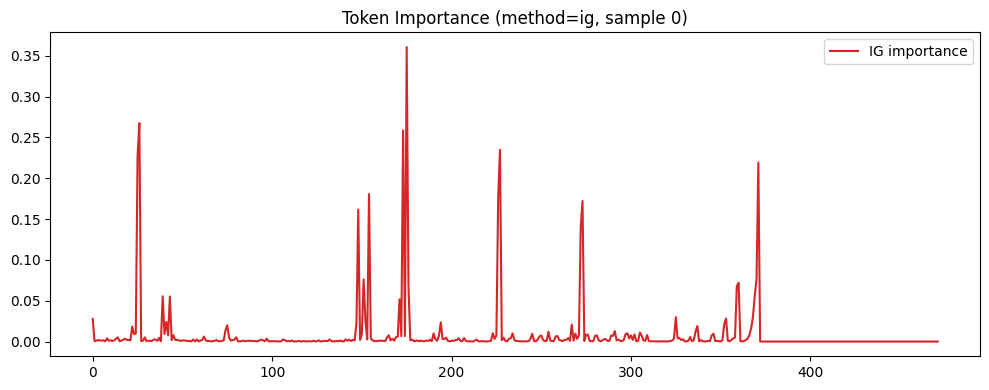

In [33]:
# === Token Importance: Attention Weights & Integrated Gradients ===
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def get_attn_token_weights(model: torch.nn.Module, x: torch.Tensor):
    """
    Extract per-token attention weights from AttentionPoolingWithTimeExtractor.
    Returns attn_weights [B, L] and mask [B, L].
    """
    # Base forward to get encoder outputs & mask
    enc_out, non_pad_mask, _ = model.base_model(x)  # [B, L, D], [B, L, 1]
    mask = non_pad_mask.squeeze(-1)                 # [B, L]

    # Extra inputs: event_time for attn_time extractor
    extra = {}
    if hasattr(model.base_model.input_adapter, 'get_extra_inputs'):
        extra = model.base_model.input_adapter.get_extra_inputs(x)
    if 'event_time' not in extra:
        raise RuntimeError("Extractor requires 'event_time' in extra inputs")

    event_time = extra['event_time'].unsqueeze(-1)  # [B, L, 1]
    pooling_input = torch.cat([enc_out, event_time], dim=-1)  # [B, L, D+1]

    # Forward through attention pooling to get weights
    _, attn_weights = model.extractor.pool(pooling_input, mask)  # [B, D+1], [B, L]
    return attn_weights, mask


def integrated_gradients_token_importance(model: torch.nn.Module, x: torch.Tensor, baseline: torch.Tensor | None = None, n_steps: int = 50):
    """
    Integrated Gradients for per-token importance on input batch tensor `x`.
    Aggregates absolute attributions across feature channels to produce [B, L] scores.
    """
    model.eval()
    device = next(model.parameters()).device
    x = x.to(device)
    if baseline is None:
        baseline = torch.zeros_like(x)
    else:
        baseline = baseline.to(device)

    delta = x - baseline
    total_grad = torch.zeros_like(x)

    alphas = torch.linspace(0.0, 1.0, steps=n_steps, device=device)
    for alpha in alphas:
        xa = (baseline + alpha * delta).detach().requires_grad_(True)
        with torch.enable_grad():
            y = model(xa)
            if y.ndim > 0:
                y = y.sum()
            model.zero_grad(set_to_none=True)
            y.backward()
            ga = xa.grad
            total_grad = total_grad + ga

    avg_grad = total_grad / n_steps
    attributions = avg_grad * delta
    token_scores = attributions.abs().sum(dim=-1)  # [B, L]
    return token_scores


def gradient_saliency_token_importance(model: torch.nn.Module, x: torch.Tensor):
    model.eval()
    device = next(model.parameters()).device
    x = x.to(device).detach().requires_grad_(True)
    with torch.enable_grad():
        y = model(x)
        if y.ndim > 0:
            y = y.sum()
        model.zero_grad(set_to_none=True)
        y.backward()
        sal = x.grad.abs().sum(dim=-1)
    return sal


# Compute by specified method (no try/except)
if 'x' in globals():
    compute_method = 'ig'  # options: 'attention' | 'ig' | 'grad'

    scores = None
    mask_plot = None
    label = ''

    if compute_method == 'attention':
        attn_w, mask_plot = get_attn_token_weights(model, x)
        scores = attn_w
        label = 'Attention weight'
    elif compute_method == 'ig':
        scores = integrated_gradients_token_importance(model, x, baseline=None, n_steps=32)
        label = 'IG importance'
    elif compute_method == 'grad':
        scores = gradient_saliency_token_importance(model, x)
        label = 'Gradient saliency'
    else:
        raise ValueError(f'Unknown compute_method: {compute_method}')

    # Plot for the first sample
    s0 = scores[54].detach().cpu().numpy()
    t = np.arange(len(s0))
    plt.figure(figsize=(10,4))
    plt.plot(t, s0, label=label, color='tab:red')
    if mask_plot is not None:
        m0 = mask_plot[0].detach().cpu().numpy().astype(bool)
        plt.scatter(t[m0], s0[m0], s=10, color='tab:red')
    plt.title(f'Token Importance (method={compute_method}, sample 0)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Variable `x` not found; skip demo.')


In [ ]:
# 绘制最后一个样本的第3号特征随时间的曲线
s = x[-1, :, 3].detach().cpu().numpy()
valid = (x[-1].abs().sum(dim=-1) > 0).detach().cpu().numpy()
idx = t if 't' in globals() and len(t) == len(s) else np.arange(len(s))

plt.figure(figsize=(10,4))
plt.plot(idx, s, color='tab:blue', lw=1)
plt.scatter(idx[valid], s[valid], s=8, color='tab:blue', alpha=0.8)
plt.title('Sample -1, feature 3')
plt.xlabel('Token index')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

tensor([0.2463, 0.2442, 0.2461, 0.2455, 0.2447, 0.6775, 0.7009, 0.5500, 0.4601,
        0.7034, 0.5263, 0.5188, 0.6865, 0.5189, 0.9625, 0.2630, 0.1165, 0.6858,
        0.2466, 0.2467, 0.6869, 0.9371, 0.6992, 0.6884, 0.7040, 0.7019, 0.7000,
        0.6158, 0.7014, 0.9496, 0.6865, 0.6860, 0.7356, 0.8165, 0.6855, 0.7492,
        0.6994, 0.5555, 0.9925, 0.2128, 0.6825, 0.5548, 0.5475, 0.6885, 0.6841,
        0.6862, 0.6275, 0.6844, 0.9060, 0.2594, 0.0885, 0.6037, 0.5312, 0.9473,
        0.6835, 0.6603, 0.5300, 0.6851, 0.1937, 0.5541, 0.6836, 0.2711, 0.9600,
        0.9592, 0.7046, 0.6873, 0.5255, 0.2256, 0.2261, 0.6046, 0.5519, 0.5456,
        0.2177, 0.5454, 0.5552, 0.8400, 0.5575, 0.2141, 0.6554, 0.5534, 0.3893,
        0.9344, 0.3918, 0.2631, 0.9797, 0.6850, 0.6764, 0.5494, 0.2285, 0.2298,
        0.5882, 0.5136, 0.5470, 0.6850, 0.5109, 0.6554, 0.6851, 0.4910, 0.5460,
        0.5225, 0.9634, 0.9569, 0.5865, 0.4765, 0.5139, 0.0825, 0.5850, 0.3901,
        0.3894, 0.6610, 0.3916, 0.3926, 